In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In this notebook, I want to see if we apply langevin dynamics (dynamics and not equation) on log-normal score and implement it, how does the converging distribution look (do we converge at all ?, if we do converge, do we go to log normal density). 

we know langevin dynamics is given by

\begin{align*}
    dX_{t} = \nabla_{x} \log p(X_{t}) dt + \sqrt{2}dB_{t}
\end{align*}

where $p$ is distribution over a random variable. Let $q(x, t)$ be the distribution that is followed by $X$ and by fokker planck equation we know

\begin{align*}
    \frac{\partial q(x, t)}{\partial t} = -\frac{\partial}{\partial t}\{q(x, t)\nabla_{x} \log p(x)\} + \frac{1}{2}\frac{\partial^{2}}{\partial x^{2}}\{2q(x, t)\}
\end{align*}

At the stationary we can easily check that $\bar{q}(x) = q(x, t)$ is equal to $p(x)$. So fokker planck says that we should converge to $p$ but let's see is it true. See this : https://en.wikipedia.org/wiki/Metropolis-adjusted_Langevin_algorithm


The log normal density is given by

\begin{align*}
    p(x) = \frac{1}{\sqrt{2\pi\sigma}}\frac{1}{x}e^{-\frac{(log(x) - \mu)^{2}}{2\sigma^{2}}}
\end{align*}

Taking the log we will get

\begin{align*}
    \log p(x) = -\frac{1}{2}\log 2\pi\sigma - \log x - \frac{1}{2\sigma^{2}}(\log x - \mu)^{2}
\end{align*}

and taking the derivative we get

\begin{align*}
    \nabla_{x} \log p(x) &= -\frac{1}{x} - \frac{1}{\sigma^{2}}\frac{1}{x}(\log x - \mu) \\
    &= -\frac{1}{x}\left(1 + \frac{1}{\sigma^{2}}(\log x - \mu)\right)
\end{align*}


So we have

\begin{align*}
    dX_{t} = -\frac{1}{X_{t}}\left(1 + \frac{1}{\sigma^{2}}(\log X_{t} - \mu)\right) + \sqrt{2}dB_{t}
\end{align*}


The discretization implementation will be

\begin{align*}
    X_{n+1} - X_{n} = -\frac{1}{X_{n}}\left(1 + \frac{1}{\sigma^{2}}(\log X_{n} - \mu)\right)\delta + \sqrt{2\delta}z
\end{align*}

where $z \sim \mathcal{N}(0, 1)$

In [2]:
def update(x, mu, sigma, delta):
    term = 1/x * (1 + (np.log(x) - mu) / sigma**2) * delta
    xnew = x - term + np.sqrt(2 * delta) * np.random.normal(0, 1)
    return xnew


def get_one_sample(x0, mu, sigma, delta, iters):
    for _ in range(iters):
        x0 = update(x0, mu, sigma, delta)

    return x0


x0 = 1
mu = 2
sigma = 1
delta = 1e-2

npaths = 10000
samples = []

for _ in range(npaths):
    samples.append(get_one_sample(x0, mu, sigma, delta, iters=10000))


samples = np.array(samples)
print(samples.shape)

/tmp/ipykernel_8637/2728575574.py:2: RuntimeWarning: invalid value encountered in log
  term = 1/x * (1 + (np.log(x) - mu) / sigma**2) * delta


(10000,)


In [7]:
np.mean(np.log(samples[~np.isnan(samples)])), np.var(np.log(samples[~np.isnan(samples)]))

(1.7770908521035278, 0.7187833972080111)

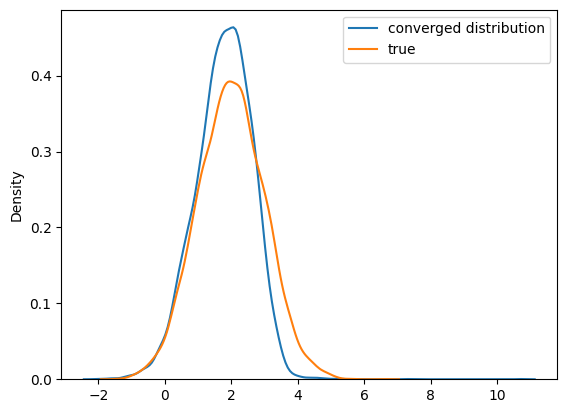

In [5]:
sns.kdeplot(np.log(samples[~np.isnan(samples)]), label="converged distribution")
sns.kdeplot(np.random.normal(mu, sigma, size=(10000,)), label="true")
plt.legend()
plt.show()